In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
%matplotlib inline

%load_ext autoreload
%autoreload 2

from waxa import atomdata
from waxa.plotting.plotting_2d import mixOD_grid

font = 'DejaVu Sans'
# font = 'Helvetica Neue'
plt.rcParams['figure.dpi'] = 200
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font]
plt.rcParams['mathtext.fontset'] = 'custom'

In [3]:
ad = atomdata(0)

No ROI saved in run 64060.
Specify the new ROI.


<Figure size 1280x960 with 0 Axes>

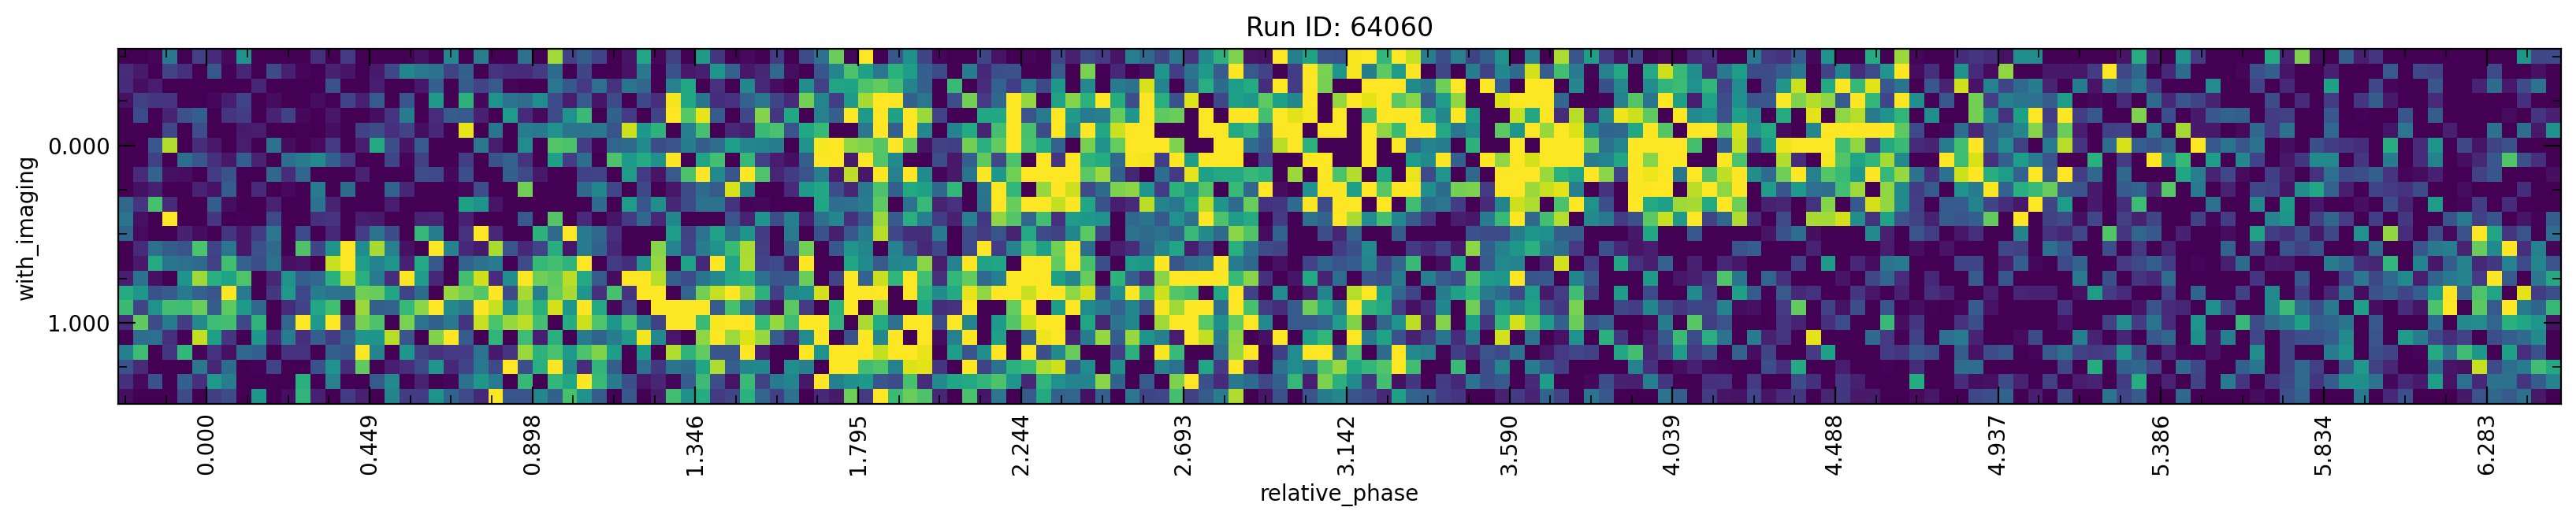

In [4]:
plt.set_cmap("viridis")
mixOD_grid(ad,
           ad.od,
            max_od=2.,
            xvarformat='1.3f',
            figsize=[20,3],
            aspect='equal')
plt.show()

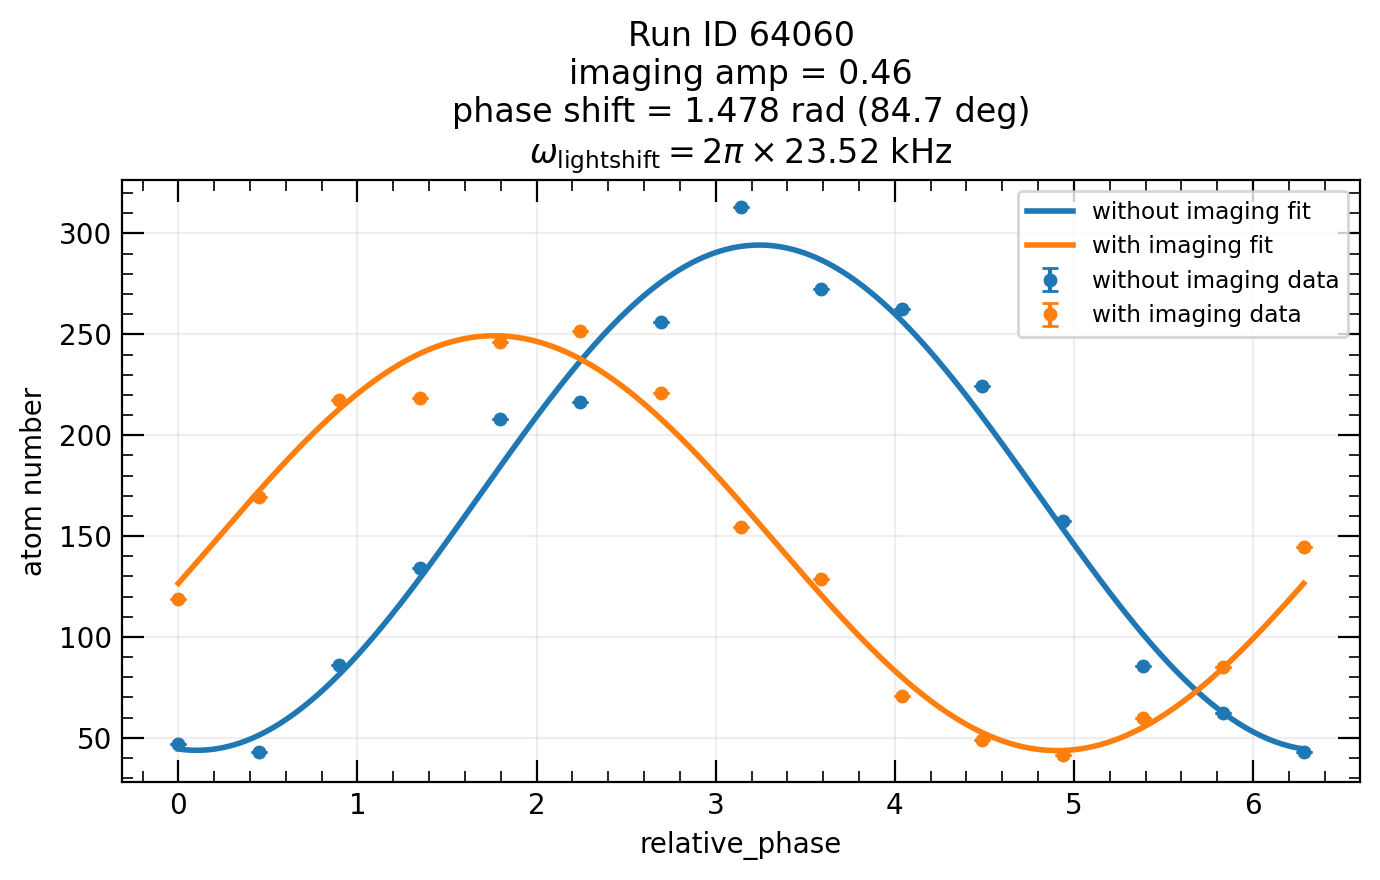

self.p.omega_lightshift = 2 * np.pi * 2.35e+04  # rad/s, for imaging amp 0.46


In [5]:
from scipy.optimize import curve_fit
from kamo import constants as c

xvar0_name = str(ad.xvarnames[0])
xvar1_name = str(ad.xvarnames[1])
xvar0 = np.asarray(ad.xvars[0])
xvar1 = np.asarray(ad.xvars[1], dtype=float)
atom_number = np.asarray(ad.atom_number, dtype=float)

if atom_number.ndim != 2:
    raise ValueError(f"Expected ad.atom_number to be 2D, got shape {atom_number.shape}")
if atom_number.shape[0] != len(xvar0):
    raise ValueError(
        f"Expected len(ad.xvars[0]) == ad.atom_number.shape[0], got {len(xvar0)} and {atom_number.shape[0]}"
    )
if atom_number.shape[1] != len(xvar1):
    raise ValueError(
        f"Expected len(ad.xvars[1]) == ad.atom_number.shape[1], got {len(xvar1)} and {atom_number.shape[1]}"
    )

def wrap_phase(phase):
    return phase % (2 * np.pi)

def cosine_model(phase, amplitude, phase_offset, offset):
    return amplitude * np.cos(phase + phase_offset) + offset

def omega_phase_shift(phase_shift, t_imaging_pulse):
    return abs(phase_shift / t_imaging_pulse)

def classify_imaging_state(value):
    if isinstance(value, (bool, np.bool_)):
        return "on" if value else "off"
    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        numeric_value = None

    if numeric_value is not None:
        if np.isclose(numeric_value, 0):
            return "off"
        if np.isclose(numeric_value, 1):
            return "on"

    value_str = str(value).strip().lower()
    if value_str in {"0", "off", "false", "no"}:
        return "off"
    if value_str in {"1", "on", "true", "yes"}:
        return "on"
    return None

def format_group_label(value):
    state = classify_imaging_state(value)
    if state == "off":
        return "without imaging"
    if state == "on":
        return "with imaging"
    return f"{xvar0_name} = {value}"

def fit_trace(phase_values, signal_values):
    valid = np.isfinite(phase_values) & np.isfinite(signal_values)
    x_fit = phase_values[valid]
    y_fit = signal_values[valid]

    amplitude_guess = 0.5 * (np.nanmax(y_fit) - np.nanmin(y_fit))
    offset_guess = np.nanmean(y_fit)
    phase_guess = -x_fit[np.nanargmax(y_fit)]
    popt, pcov = curve_fit(
        cosine_model,
        x_fit,
        y_fit,
        p0=[amplitude_guess, phase_guess, offset_guess],
        maxfev=20000,
    )

    amplitude_fit, phase_fit, offset_fit = popt
    if amplitude_fit < 0:
        amplitude_fit = -amplitude_fit
        phase_fit += np.pi

    popt = np.array([amplitude_fit, wrap_phase(phase_fit), offset_fit])
    return popt, pcov

ordered_xvar0_values = list(dict.fromkeys(xvar0.tolist()))
if len(ordered_xvar0_values) != 2:
    raise ValueError(f"Expected exactly two {xvar0_name} groups, found {ordered_xvar0_values}")

group_results = []
for value in ordered_xvar0_values:
    group_mask = xvar0 == value
    group_data = atom_number[group_mask]
    group_mean = np.nanmean(group_data, axis=0)
    valid_counts = np.sum(np.isfinite(group_data), axis=0)
    group_sem = np.zeros_like(group_mean)
    repeated_points = valid_counts > 1
    if np.any(repeated_points):
        group_sem[repeated_points] = (
            np.nanstd(group_data[:, repeated_points], axis=0, ddof=1)
            / np.sqrt(valid_counts[repeated_points])
        )
    fit_params, fit_cov = fit_trace(xvar1, group_mean)

    group_results.append({
        "value": value,
        "state": classify_imaging_state(value),
        "label": format_group_label(value),
        "mean": group_mean,
        "sem": group_sem,
        "fit_params": fit_params,
        "fit_cov": fit_cov,
    })

state_priority = {"off": 0, "on": 1, None: 2}
group_results.sort(key=lambda item: state_priority.get(item["state"], 2))

phase_grid = np.linspace(np.nanmin(xvar1), np.nanmax(xvar1), 1000)
color_map = {"off": "tab:blue", "on": "tab:orange", None: "tab:green"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for result in group_results:
    color = color_map.get(result["state"], "tab:green")
    ax.errorbar(
        xvar1,
        result["mean"],
        yerr=result["sem"],
        fmt="o",
        ms=4,
        capsize=3,
        color=color,
        label=f"{result['label']} data",
    )
    ax.plot(
        phase_grid,
        cosine_model(phase_grid, *result["fit_params"]),
        color=color,
        lw=2,
        label=f"{result['label']} fit",
    )

phase_by_state = {result["state"]: result["fit_params"][1] for result in group_results}
if "off" in phase_by_state and "on" in phase_by_state:
    phase_shift = (phase_by_state["on"] - phase_by_state["off"]) % (2 * np.pi)
else:
    phase_shift = (group_results[1]["fit_params"][1] - group_results[0]["fit_params"][1]) % (2 * np.pi)

def omega_phase_shift(phase_shift, t_imaging_pulse):
    return abs(phase_shift / t_imaging_pulse)
f_lightshift = omega_phase_shift(phase_shift, t_imaging_pulse=ad.p.t_ramsey) / (2 * np.pi)

ax.set_xlabel(xvar1_name)
ax.set_ylabel("atom number")
ax.set_title(
    f"Run ID {ad.run_info.run_id}\n"
    f"imaging amp = {ad.p.amp_imaging:1.2f}\n"
    f"phase shift = {phase_shift:.3f} rad ({np.degrees(phase_shift):.1f} deg)\n"
    f"$\\omega_\\text{{lightshift}} = 2 \\pi \\times {f_lightshift/1.e3:1.2f}$ kHz"
)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'self.p.omega_lightshift = 2 * np.pi * {f_lightshift:.3g}  # rad/s, for imaging amp {ad.p.amp_imaging}')